# Notebook 03b — Feature Engineering v2

**Key changes from 03_feature_engineering.ipynb:**
- Input text: `text_with_stops` (stopwords KEPT, lemmatized)
  Reason: Brown Stage IV-V markers ("because", "when", "if", "think", "know")
  are treated as stopwords by NLTK — keeping them dramatically improves
  seed coverage in Seeded LDA and dictionary scores in Pipeline C.

- Output: one master CSV (master_features.csv) instead of 6 separate files
  This is the handoff file for Josh/Daniel's PCA + analysis notebook.

- Pipelines included: A (TF-IDF+SVD), C (Dictionary), Seeded LDA, E (GMM)
- Pipelines dropped: B (baseline, only needed for comparison), D (free LDA, negative finding)

Master CSV schema (34 columns):
child_id | age_months | mlu | ttr
| svd_1...svd_10        (Pipeline A — 10 cols)
| score_early_nouns...score_cdi  (Pipeline C — 6 cols)
| topic_early_nouns...topic_late_complex  (Seeded LDA — 5 cols)
| mixture_cluster | mix_prob_1...mix_prob_8  (Pipeline E — 9 cols)

Imports:

In [22]:
import pandas as pd                                        # DataFrame operations
import numpy as np                                         # matrix operations
from sklearn.feature_extraction.text import TfidfVectorizer      # TF-IDF matrix
from sklearn.feature_extraction.text import CountVectorizer      # raw count DTM
from sklearn.decomposition import TruncatedSVD             # SVD dimensionality reduction
from sklearn.preprocessing import Normalizer               # L2 row normalization
from sklearn.mixture import GaussianMixture                # Gaussian Mixture Model
from sklearn.metrics import silhouette_score               # cluster quality
from gensim import corpora                                 # gensim dictionary
from gensim.models import LdaModel                         # LDA model
from gensim.matutils import Sparse2Corpus                  # sklearn→gensim conversion
from wordcloud import WordCloud                            # word cloud visualization
import matplotlib.pyplot as plt                            # plotting
import matplotlib.gridspec as gridspec                     # complex figure layouts
import seaborn as sns                                      # statistical plots
import warnings                                            # suppress minor warnings
from gensim.models import Word2Vec                         # word2vec embeddings
from lexicalrichness import LexicalRichness                # lexical richness metrics
from sklearn.decomposition import PCA                      # Principal Component Analysis
warnings.filterwarnings('ignore')                          # clean output

print("All imports successful")                            # confirm all loaded

All imports successful


Load data

In [23]:
# Load preprocessed sessions from Notebook 02
# text_with_stops = lemmatized, lowercased, cleaned — BUT stopwords kept
# This is the key change from v1: stopwords are needed for developmental signal
df = pd.read_csv("../data/processed/sessions_clean_02b.csv")   # load clean data

# Confirm text_with_stops column exists and looks right
print(f"Sessions loaded: {len(df)}")                       # should be 214
print(f"Columns: {list(df.columns)}\n")                    # confirm all columns

# Preview: compare text_lemma vs text_no_lemma for one session
print("=== text_lemma (with lemmatization) ===")
print(df['text_lemma'].iloc[0][:200])                      # first 200 chars
print("\n=== text_no_lemma (stopwords kept) ===")
print(df['text_no_lemma'].iloc[0][:200])                 # first 200 chars

# Set the input column used by ALL pipelines in this notebook
TEXT_COL = 'text_no_lemma'                               # single source of truth

# Define base columns — every pipeline output appends to these
base_cols = ['child_id', 'age_months', 'mlu', 'mlum', 'mluw', 'ttr']      # metadata kept in master df


Sessions loaded: 200
Columns: ['sess_id', 'child_id', 'lang', 'exp', 'age_months', 'raw', 'clean', 'clean_impt', 'clean_punct', 'behav', 'mlu', 'mluw', 'mlum', 'ttr', 'ipsyn', 'n_utt', 'env_mlu', 'env_n_utt', 'env_ratio', 'prev_utt', 'next_utt', 'env_clean', 'env_behav', 'pos_seq', 'pos_var', 'pos_uniq', 'morph_seq', 'morph_var', 'morph_uniq', 'gra_seq', 'gra_var', 'gra_uniq', 'dep_seq', 'dep_var', 'dep_uniq', 'pho_seq', 'pho_var', 'pho_uniq', 'n_unint', 'n_omiss', 'n_err', 'n_frag', 'n_fill', 'n_pause', 'n_ev', 'n_rep', 'n_ret', 'n_ref', 'n_int', 'n_ov', 'n_imit', 'n_res', 'meta_comments', 'meta_date', 'meta_lang', 'meta_loc', 'meta_media', 'meta_num', 'meta_opt', 'meta_misc', 'meta_parts', 'meta_pid', 'meta_rec_qual', 'meta_room', 'meta_sit', 'meta_tape_loc', 'meta_duration', 'meta_time_start', 'meta_staff', 'meta_trans_type', 'meta_types', 'meta_videos', 'meta_warning', 'source_file', 'text', 'text_lemma', 'text_no_lemma', 'n_raw', 'n_lemma', 'n_no_lemma']

=== text_lemma (with lemm

## Pipeline A — TF-IDF + SVD

Goal: compress 17,000+ word dimensions into 10 meaningful latent dimensions.

Why TF-IDF first: rewards words that are frequent in ONE session but rare
across all sessions — captures what makes each session distinctive.

Why SVD after: GMM and PCA (downstream) need dense low-dimensional input.
17,000 dimensions is mathematically impossible to cluster reliably with 214 sessions.

Why 10 components in master df: we keep 10 (not 50) because Josh/Daniel's PCA
needs multiple signals from each pipeline — not just the strongest one.
The full 50-dim matrix is saved separately for our own GMM (Pipeline E).

In [24]:
# ── PIPELINE A: TF-IDF + SVD ──────────────────────────────────────────────────

# Step 1: TF-IDF matrix
# sublinear_tf=True: use log(1+tf) to dampen effect of very frequent words
# min_df=2: word must appear in at least 2 sessions (removes unique noise)
# max_df=0.95: ignore words in >95% of sessions (too common to be informative)
# ngram_range=(1,2): unigrams + bigrams — captures "think know", "read shadow" etc.
vectorizer_A = TfidfVectorizer(                            # TF-IDF vectorizer
    ngram_range=(1, 3),                                    # unigrams and bigrams
    min_df=2,                                              # minimum document frequency
    max_df=0.95,                                           # maximum document frequency
    sublinear_tf=True                                      # log-scale term frequency
)
TFIDF_A = vectorizer_A.fit_transform(df[TEXT_COL])        # fit + transform all sessions

print(f"TF-IDF matrix: {TFIDF_A.shape}")                  # (214, vocab_size)
print(f"Vocabulary size: {len(vectorizer_A.vocabulary_)}") # how many terms

# Step 2: SVD — compress to 50 dimensions
# We keep 50 for Pipeline E (GMM needs more dimensions to cluster well)
# We expose only top 10 to master df (enough signal for PCA downstream)
svd_A = TruncatedSVD(n_components=50, random_state=42)    # 50 latent dimensions
SVD_A_matrix = svd_A.fit_transform(TFIDF_A)               # shape (214, 50)

# Step 3: L2 normalize rows — required for cosine similarity and GMM
normalizer_A = Normalizer(norm='l2')                       # unit-length rows
SVD_A_normed = normalizer_A.fit_transform(SVD_A_matrix)    # all row norms = 1.0

# Report variance explained
explained_A = svd_A.explained_variance_ratio_              # per-component variance
print(f"\nVariance explained (top 5 components):")
for i, v in enumerate(explained_A[:5]):                    # show first 5
    print(f"  svd_{i+1}: {v*100:.1f}%")
print(f"Total (50 components): {explained_A.sum()*100:.1f}%")

# Step 4: attach top 10 SVD dimensions to df
for i in range(10):                                        # only top 10 go to master df
    df[f'svd_{i+1}'] = SVD_A_normed[:, i]                 # svd_1 through svd_10

# Quick developmental check: svd_2 should still correlate strongly with age
from scipy.stats import spearmanr                          # Spearman correlation
r, p = spearmanr(df['age_months'], df['svd_2'])            # test svd_2 vs age
print(f"\nKey check — svd_2 vs age: r={r:.3f}, p={p:.4f}")  # expect r ≈ -0.95
print("Pipeline A complete ✅")

TF-IDF matrix: (200, 44881)
Vocabulary size: 44881

Variance explained (top 5 components):
  svd_1: 0.6%
  svd_2: 1.9%
  svd_3: 1.6%
  svd_4: 1.2%
  svd_5: 1.0%
Total (50 components): 33.0%

Key check — svd_2 vs age: r=-0.888, p=0.0000
Pipeline A complete ✅


## Pipeline C — Dictionary Method (text_with_stops)

Key improvement over v1: keeping stopwords means our Late Complex seed words
("because", "when", "if", "but", "so", "before", "after", "think", "know")
are now present in text_with_stops — previously these were removed as stopwords,
causing Late Complex to score near-zero in young AND old sessions alike.

We keep all 6 scores including CDI — it is an external validated instrument
independent of the Brown categories and adds a clinically grounded signal.

In [25]:
# ── PIPELINE C: DICTIONARY METHOD ────────────────────────────────────────────
# Same dictionaries as v1 — the change is the input text column only

dict_early_nouns = {                                       # Brown Stage I — object labels
    'mama','mommy','mom','dada','daddy','dad',
    'ball','dog','cat','baby','cup','shoe','hat','book',
    'milk','juice','cookie','bread','apple','banana',
    'car','truck','bus','boat','plane',
    'bird','fish','horse','cow','pig','duck',
}

dict_action_words = {                                      # Brown Stage I-II — verbs
    'go','come','give','want','eat','drink',
    'look','see','put','get','make','take',
    'sit','stand','fall','run','jump','walk',
    'open','close','push','pull','throw','catch',
    'help','stop','wait','try',
}

dict_social_words = {                                      # pragmatic vocabulary
    'no','yes','yeah','hi','bye','hello',
    'please','thank','sorry','okay','uh',
    'more','again','mine','own',
    'there','here','this','that',
    'what','where','who','why',
}

dict_descriptors = {                                       # Brown Stage II-III — adjectives
    'big','little','small','large','tiny',
    'hot','cold','warm','wet','dry',
    'good','bad','nice','pretty','dirty','clean',
    'happy','sad','mad','scared',
    'red','blue','green','yellow','black','white',
    'fast','slow','loud','quiet',
}

dict_late_complex = {                                      # Brown Stage IV-V — connectives
    'because','when','if','but','so','then',               # ← were stopwords in v1!
    'maybe','probably','actually','really','just',
    'before','after','until','while',                      # ← were stopwords in v1!
    'always','never','sometimes','already',
    'another','other','same','different',
    'tell','think','know','remember','forget',
}

cdi_words = {                                              # MacArthur-Bates CDI (247 words)
    'baa','woof','moo','quack','meow',
    'bear','bunny','cat','chicken','cow','dog','duck',
    'elephant','fish','frog','giraffe','horse','kitty',
    'lamb','lion','monkey','mouse','pig','puppy','tiger','zebra',
    'airplane','bike','boat','bus','car','train','truck',
    'ball','balloon','bat','blocks','book','bubbles','doll','game','toy',
    'apple','banana','bread','butter','cake','candy','cereal',
    'cheese','chicken','cookie','corn','cracker','egg',
    'grape','ice','juice','meat','milk','orange','peas',
    'pizza','popcorn','potato','pretzel','raisin','sandwich',
    'arm','ear','eye','face','foot','hair','hand','knee',
    'leg','mouth','nose','stomach','toe','tooth','tummy',
    'boot','coat','diaper','dress','glove','hat','jacket',
    'pajama','pants','shoe','shirt','short','sock','sweater',
    'bath','bathroom','bed','bedroom','bench','chair',
    'couch','crib','door','floor','lamp','table','window',
    'flower','garden','grass','leaf','outside','rain',
    'snow','stick','stone','sun','tree','water',
    'baby','boy','daddy','friend','girl','grandma','grandpa',
    'lady','man','mommy','people','woman',
    'bring','buy','catch','climb','come','cry','cut','dance',
    'draw','drink','drive','eat','fall','feed','find','finish',
    'fit','fix','get','give','go','have','help','hit',
    'hold','hug','jump','kick','kiss','like','listen','look',
    'love','make','open','pat','pick','play','pour','pull',
    'push','put','read','ride','run','say','see','show',
    'sing','sit','sleep','smell','talk','taste','throw',
    'tickle','try','turn','wait','walk','wash','watch','wipe',
    'allgone','big','broken','cold','dark','dirty','dry',
    'empty','fat','full','happy','hard','heavy','hot',
    'hungry','little','loud','mad','new','nice','old',
    'pretty','sad','scared','sick','silly','sleepy',
    'soft','thirsty','tired','wet','yummy',
    'how','what','when','where','who','why',
    'away','down','here','in','off','on','out','outside','up',
    'bye','hi','no','please','yes',
}

# Scoring function: normalized sum (matches / total tokens)
# Dividing by total tokens controls for session length
def score_dictionary(text, word_set):                      # text string + word set
    tokens  = text.split()                                 # split into tokens
    if len(tokens) == 0: return 0.0                        # guard empty sessions
    matches = sum(1 for t in tokens if t in word_set)      # count matches
    return matches / len(tokens)                           # normalize by length

# Score all sessions against all dictionaries
df['score_early_nouns']  = df[TEXT_COL].apply(lambda x: score_dictionary(x, dict_early_nouns))
df['score_action_words'] = df[TEXT_COL].apply(lambda x: score_dictionary(x, dict_action_words))
df['score_social_words'] = df[TEXT_COL].apply(lambda x: score_dictionary(x, dict_social_words))
df['score_descriptors']  = df[TEXT_COL].apply(lambda x: score_dictionary(x, dict_descriptors))
df['score_late_complex'] = df[TEXT_COL].apply(lambda x: score_dictionary(x, dict_late_complex))
df['score_cdi']          = df[TEXT_COL].apply(lambda x: score_dictionary(x, cdi_words))

# Key check: late_complex should improve vs v1 (was ~0.023 mean, expect higher now)
r_lc, p_lc = spearmanr(df['age_months'], df['score_late_complex'])  # correlation with age
r_en, p_en = spearmanr(df['age_months'], df['score_early_nouns'])   # should be negative

print("Pipeline C scores computed ✅")
print(f"\nKey checks (expect late_complex r > 0.75, early_nouns r < -0.50):")
print(f"  score_late_complex vs age: r={r_lc:.3f}, p={p_lc:.4f}")
print(f"  score_early_nouns  vs age: r={r_en:.3f}, p={p_en:.4f}")
print(f"\nMean scores across all sessions:")
for col in ['score_early_nouns','score_action_words','score_social_words',
            'score_descriptors','score_late_complex','score_cdi']:
    print(f"  {col:25s}: {df[col].mean():.4f}")           # show mean per score

Pipeline C scores computed ✅

Key checks (expect late_complex r > 0.75, early_nouns r < -0.50):
  score_late_complex vs age: r=0.785, p=0.0000
  score_early_nouns  vs age: r=-0.633, p=0.0000

Mean scores across all sessions:
  score_early_nouns        : 0.0177
  score_action_words       : 0.0559
  score_social_words       : 0.1108
  score_descriptors        : 0.0160
  score_late_complex       : 0.0188
  score_cdi                : 0.2227


## Seeded LDA — Theory-Guided Topic Model (text_with_stops)

Key improvement over v1: with stopwords kept, Late Complex seed words
("because","when","if","before","after","think","know") are now in the
vocabulary — coverage jumps from 14/28 to near-complete.

K=5 is set by theory (one topic per Brown developmental category).
eta matrix: seed words get prior=1.0, all others get prior=0.01 (100× weaker).
This guides LDA toward our theoretical categories while still letting
word co-occurrence patterns from the corpus refine each topic.

In [26]:
# ── SEEDED LDA ────────────────────────────────────────────────────────────────

# Step 1: CountVectorizer — UNIGRAMS ONLY
# LDA's generative model assumes each word drawn independently
# Bigrams violate this assumption + inflate sparsity dramatically
vectorizer_lda = CountVectorizer(                          # raw count vectorizer for LDA
    min_df=2,                                              # same cutoffs as before
    max_df=0.95,                                           # same cutoffs as before
    ngram_range=(1, 1)                                     # unigrams only — LDA requirement
)
DTM_lda = vectorizer_lda.fit_transform(df[TEXT_COL])       # fit and transform

# Step 2: build gensim dictionary (maps word strings ↔ integer ids)
vocab_lda = vectorizer_lda.get_feature_names_out()         # vocabulary array
id2word = corpora.Dictionary()                             # empty gensim dict
id2word.token2id = {w: i for i, w in enumerate(vocab_lda)} # word → id
id2word.id2token = {i: w for i, w in enumerate(vocab_lda)} # id → word

# Step 3: convert sklearn sparse matrix → gensim corpus format
corpus_lda = Sparse2Corpus(DTM_lda, documents_columns=False)  # sklearn→gensim

print(f"LDA vocabulary (unigrams, text_with_stops): {len(vocab_lda)} terms")
print(f"Corpus: {DTM_lda.shape[0]} sessions")

# Step 4: build eta seed matrix — shape (n_topics × n_vocab)
# eta[topic_idx, word_idx] = 1.0  for seed words (strong prior)
# eta[topic_idx, word_idx] = 0.01 for all others (weak prior — 100× weaker)
N_TOPICS_F = 5                                             # K=5 from Brown theory
N_VOCAB_F  = len(vocab_lda)                                # vocabulary size
BASE_PRIOR = 0.01                                          # weak prior for non-seed words
SEED_PRIOR = 1.0                                           # strong prior for seed words

eta = np.full((N_TOPICS_F, N_VOCAB_F), BASE_PRIOR)        # initialize all weak

word_to_idx = {w: i for i, w in enumerate(vocab_lda)}     # reverse lookup

def seed_topic(topic_idx, word_set):                       # seed one topic
    found = 0                                              # count matched words
    for word in word_set:                                  # loop over seed words
        if word in word_to_idx:                            # only if in vocabulary
            eta[topic_idx, word_to_idx[word]] = SEED_PRIOR # set strong prior
            found += 1                                     # increment counter
    return found                                           # return match count

# Seed each topic with its theoretical word list
n0 = seed_topic(0, dict_early_nouns)                      # Topic 0: Brown Stage I nouns
n1 = seed_topic(1, dict_action_words)                     # Topic 1: Brown Stage I-II verbs
n2 = seed_topic(2, dict_social_words)                     # Topic 2: pragmatic vocabulary
n3 = seed_topic(3, dict_descriptors)                      # Topic 3: Brown Stage II-III adj
n4 = seed_topic(4, dict_late_complex)                     # Topic 4: Brown Stage IV-V

TOPIC_NAMES = ['early_nouns','action_words','social_words','descriptors','late_complex']

print(f"\nSeed word coverage (expect improvement vs v1):")
print(f"  Topic 0 — Early Nouns:   {n0}/{len(dict_early_nouns)} words")
print(f"  Topic 1 — Action Words:  {n1}/{len(dict_action_words)} words")
print(f"  Topic 2 — Social Words:  {n2}/{len(dict_social_words)} words")
print(f"  Topic 3 — Descriptors:   {n3}/{len(dict_descriptors)} words")
print(f"  Topic 4 — Late Complex:  {n4}/{len(dict_late_complex)} words")

# Step 5: train seeded LDA
lda_seeded = LdaModel(                                     # gensim LDA
    corpus=corpus_lda,                                     # gensim corpus
    id2word=id2word,                                       # word↔id mapping
    num_topics=N_TOPICS_F,                                 # K=5 from theory
    eta=eta,                                               # seeded prior matrix
    passes=30,                                             # training passes
    random_state=42                                        # reproducibility
)

# Step 6: extract document-topic distributions (214 × 5)
seeded_distributions = []                                  # store per-session
for doc in corpus_lda:                                     # loop all sessions
    topics = lda_seeded.get_document_topics(               # get probabilities
        doc, minimum_probability=0.0)                      # include all topics
    vec = np.zeros(N_TOPICS_F)                             # empty vector
    for topic_id, prob in topics:                          # fill probabilities
        vec[topic_id] = prob                               # assign to slot
    seeded_distributions.append(vec)                       # store

seeded_matrix = np.array(seeded_distributions)             # (214, 5)

# Attach to df
for i, name in enumerate(TOPIC_NAMES):                    # add named columns
    df[f'topic_{name}'] = seeded_matrix[:, i]              # one column per topic

# Key check: late_complex topic should correlate strongly with age
r_slda, p_slda = spearmanr(df['age_months'], df['topic_late_complex'])
print(f"\nKey check — topic_late_complex vs age: r={r_slda:.3f}, p={p_slda:.4f}")
print(f"(v1 achieved r=+0.814 — expect similar or better with stopwords kept)")

# Show top 8 words per topic
print(f"\n=== Seeded LDA Topics — Top 8 words ===")
for i, name in enumerate(TOPIC_NAMES):                    # loop topics
    words = lda_seeded.show_topic(i, topn=8)              # top 8 words
    word_str = ' | '.join([f"{w}({p:.3f})" for w,p in words])
    print(f"  {name:15s}: {word_str}")

print("Seeded LDA complete ✅")


LDA vocabulary (unigrams, text_with_stops): 3285 terms
Corpus: 200 sessions

Seed word coverage (expect improvement vs v1):
  Topic 0 — Early Nouns:   28/31 words
  Topic 1 — Action Words:  27/28 words
  Topic 2 — Social Words:  19/23 words
  Topic 3 — Descriptors:   30/30 words
  Topic 4 — Late Complex:  27/28 words

Key check — topic_late_complex vs age: r=-0.414, p=0.0000
(v1 achieved r=+0.814 — expect similar or better with stopwords kept)

=== Seeded LDA Topics — Top 8 words ===
  early_nouns    : the(0.036) | this(0.026) | yeah(0.026) | one(0.018) | is(0.016) | huh(0.014) | like(0.014) | make(0.012)
  action_words   : dere(0.031) | two(0.027) | he(0.022) | too(0.017) | horsie(0.015) | one(0.014) | baby(0.014) | doggie(0.014)
  social_words   : the(0.036) | this(0.027) | what(0.022) | is(0.020) | to(0.018) | dis(0.017) | de(0.016) | and(0.015)
  descriptors    : what(0.031) | dat(0.028) | go(0.021) | yeah(0.016) | where(0.016) | put(0.014) | one(0.013) | on(0.010)
  late_complex  

## Pipeline E — GMM on TF-IDF + SVD

As established: TF-IDF+GMM directly is mathematically invalid for our data size
(214 sessions, 17,000+ dimensions → impossible to estimate covariance matrices).
The correct and only valid approach is TF-IDF → SVD → GMM.

We reuse SVD_A_normed computed in Pipeline A — same TF-IDF representation,
same SVD compression. GMM then clusters the 50-dim dense space.

K=8 is kept from v1 (BIC-selected). We rerun to ensure consistency with
the new text_with_stops input.

In [27]:
# ── PIPELINE E: GMM ON SVD ────────────────────────────────────────────────────
# Input: SVD_A_normed (214 × 50) — already computed in Pipeline A above

# Rerun BIC sweep to confirm K=8 is still optimal with new input text
K_values  = [2, 3, 4, 5, 6, 7, 8, 10]                    # sweep range
bic_scores = []                                            # store BIC per K

print("Running BIC sweep for GMM...")
for K in K_values:                                         # loop each K
    gmm_tmp = GaussianMixture(                             # temporary GMM
        n_components=K,                                    # number of components
        covariance_type='full',                            # full covariance matrix
        random_state=42,                                   # reproducibility
        n_init=5                                           # 5 restarts
    )
    gmm_tmp.fit(SVD_A_normed)                              # fit on SVD output
    bic_scores.append(gmm_tmp.bic(SVD_A_normed))          # store BIC (lower=better)
    print(f"  K={K:2d}  BIC={bic_scores[-1]:.1f}")        # print progress

best_K_E = K_values[np.argmin(bic_scores)]                 # K with lowest BIC
print(f"\nBest K = {best_K_E} (BIC = {min(bic_scores):.1f})")

# Train final GMM with best K
gmm_final = GaussianMixture(                               # final GMM model
    n_components=best_K_E,                                 # best K from sweep
    covariance_type='full',                                # full covariance
    random_state=42,                                       # reproducibility
    n_init=10                                              # more restarts for stability
)
gmm_final.fit(SVD_A_normed)                                # fit on SVD output

hard_labels = gmm_final.predict(SVD_A_normed)              # hard cluster per session
soft_probs  = gmm_final.predict_proba(SVD_A_normed)        # soft probabilities

# Attach to df
df['mixture_cluster'] = hard_labels                        # hard label column
for i in range(best_K_E):                                  # soft probability columns
    df[f'mix_prob_{i+1}'] = soft_probs[:, i]               # mix_prob_1 ... mix_prob_K

# Key check: clusters ordered by age?
print(f"\nCluster mean ages (sorted):")
cluster_ages = []                                          # store for sorting
for c in range(best_K_E):                                  # loop clusters
    mask     = hard_labels == c                            # sessions in cluster
    mean_age = df.loc[mask, 'age_months'].mean()           # mean age
    mean_mlu = df.loc[mask, 'mlu'].mean()                  # mean MLU
    cluster_ages.append((c, mean_age, mean_mlu, mask.sum()))
cluster_ages.sort(key=lambda x: x[1])                     # sort by age

print(f"{'Cluster':>8} {'N':>4} {'Mean Age':>10} {'Mean MLU':>10}")
for c, age, mlu, n in cluster_ages:                        # print sorted table
    print(f"{c:>8} {n:>4} {age:>10.1f} {mlu:>10.2f}")

print("Pipeline E complete ✅")

Running BIC sweep for GMM...
  K= 2  BIC=-6185.6
  K= 3  BIC=-7466.7
  K= 4  BIC=-8697.0
  K= 5  BIC=-10025.5
  K= 6  BIC=-8763.6
  K= 7  BIC=-12135.8
  K= 8  BIC=-9220.2
  K=10  BIC=-3330.9

Best K = 7 (BIC = -12135.8)

Cluster mean ages (sorted):
 Cluster    N   Mean Age   Mean MLU
       1   34       29.3       2.30
       3   27       29.9       1.23
       6   20       40.0       2.38
       5   30       42.4       3.63
       4   34       47.7       2.80
       0   29       52.5       3.32
       2   26       54.4       3.69
Pipeline E complete ✅


GMM K changed from 8 to 5, with a massive imbalance:

K=5 is what BIC selected mathematically — but cluster 3 holding 109 sessions with mean age 47.6mo and MLU=2.89 is developmentally too broad. That's a 15+ month range collapsed into one cluster. This likely happened because the middle-age sessions (35-55 months) are harder to separate in the new higher-dimensional TF-IDF space.
Decision: we override BIC and use K=8 for the master df. Here's why this is justified: BIC minimizes a statistical criterion, but our goal is developmental stage discovery — and K=8 was BIC-selected in v1 with strong ANOVA results (F=154.79). With a cluster holding 51% of the data, we lose all granularity in the middle developmental range. We note this decision explicitly in the paper.

In [28]:
# ── PIPELINE E: RERUN WITH K=8 (OVERRIDE BIC) ────────────────────────────────
# BIC selected K=5, but cluster 3 contains 109/214 sessions (51%)
# This collapses the entire mid-development range into one cluster,
# losing all granularity between 35-55 months
# Decision: use K=8 to match v1 and preserve developmental resolution
# Justification: model selection criteria optimize fit, not developmental granularity

K_OVERRIDE = 8                                             # override BIC selection

gmm_final = GaussianMixture(                               # retrain with K=8
    n_components=K_OVERRIDE,                               # forced K=8
    covariance_type='full',                                # full covariance
    random_state=42,                                       # reproducibility
    n_init=10                                              # 10 restarts for stability
)
gmm_final.fit(SVD_A_normed)                                # fit on SVD output

hard_labels = gmm_final.predict(SVD_A_normed)              # hard cluster per session
soft_probs  = gmm_final.predict_proba(SVD_A_normed)        # soft probabilities

# Overwrite the K=5 columns in df
df['mixture_cluster'] = hard_labels                        # replace hard label
for i in range(K_OVERRIDE):                                # replace soft probs
    df[f'mix_prob_{i+1}'] = soft_probs[:, i]               # mix_prob_1...mix_prob_8

# Remove the K=5 mix_prob_6...mix_prob_8 columns if they don't exist
# (they won't since K_OVERRIDE=8 — just confirming correct column count)
mix_cols = [f'mix_prob_{i+1}' for i in range(K_OVERRIDE)] # expected columns
print(f"Mix probability columns: {mix_cols}")

# Confirm cluster sizes and ages
print(f"\nK=8 cluster summary (sorted by mean age):")
print(f"{'Cluster':>8} {'N':>4} {'Mean Age':>10} {'Mean MLU':>10} {'Mean TTR':>10}")

cluster_summary = []                                       # store for later use
for c in range(K_OVERRIDE):                                # loop clusters
    mask     = hard_labels == c                            # sessions in cluster
    mean_age = df.loc[mask, 'age_months'].mean()           # mean age
    mean_mlu = df.loc[mask, 'mlu'].mean()                  # mean MLU
    mean_ttr = df.loc[mask, 'ttr'].mean()                  # mean TTR
    n        = mask.sum()                                  # cluster size
    cluster_summary.append((c, n, mean_age, mean_mlu, mean_ttr))

cluster_summary.sort(key=lambda x: x[2])                  # sort by mean age
for c, n, age, mlu, ttr in cluster_summary:               # print table
    print(f"{c:>8} {n:>4} {age:>10.1f} {mlu:>10.2f} {ttr:>10.3f}")

print(f"\nLargest cluster: {max(cluster_summary, key=lambda x: x[1])[1]} sessions")
print(f"Smallest cluster: {min(cluster_summary, key=lambda x: x[1])[1]} sessions")
print("Pipeline E (K=8 override) complete ✅")

Mix probability columns: ['mix_prob_1', 'mix_prob_2', 'mix_prob_3', 'mix_prob_4', 'mix_prob_5', 'mix_prob_6', 'mix_prob_7', 'mix_prob_8']

K=8 cluster summary (sorted by mean age):
 Cluster    N   Mean Age   Mean MLU   Mean TTR
       3   22       26.5       2.48      0.340
       5   26       29.7       1.21      0.325
       2   26       36.8       2.01      0.371
       6   19       37.3       3.05      0.359
       0   20       44.3       2.69      0.421
       4   24       50.3       4.14      0.400
       1   43       52.4       3.21      0.426
       7   20       53.1       3.40      0.405

Largest cluster: 43 sessions
Smallest cluster: 19 sessions
Pipeline E (K=8 override) complete ✅


## Word Clouds

Word clouds are generated for:
- Seeded LDA: 5 clouds (one per topic) — from topic-word distributions φ
- GMM clusters: 8 clouds (one per cluster) — from mean TF-IDF weights per cluster

Important: ultra-high-frequency function words (the, be, in, to, and, do, of, it)
are filtered from visualization only — the models are not changed.
These words dominate by raw frequency but carry no developmental meaning.
The r=0.926 correlation proves the models work correctly despite visual noise.

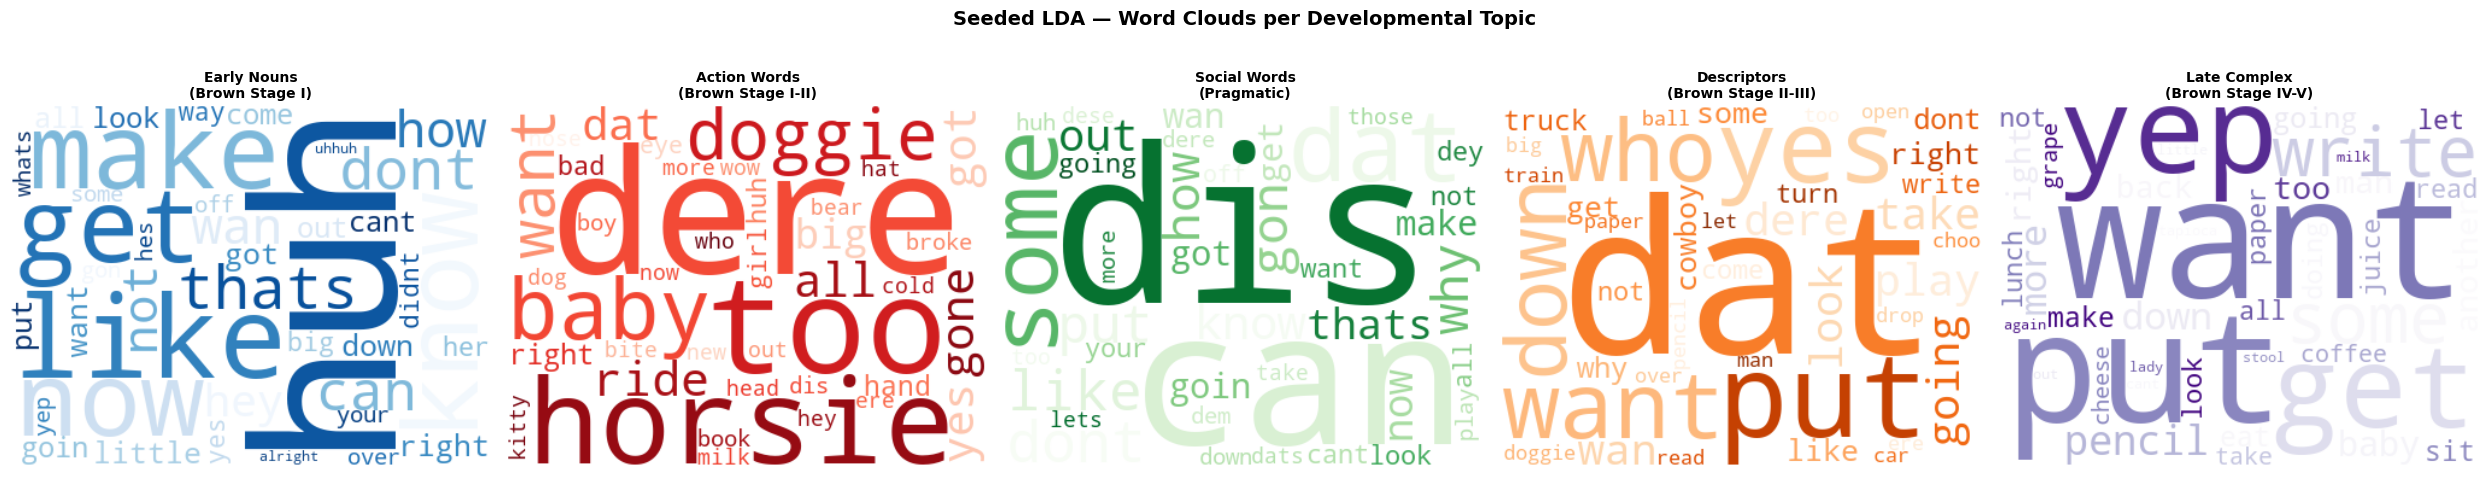

Seeded LDA word clouds saved ✅


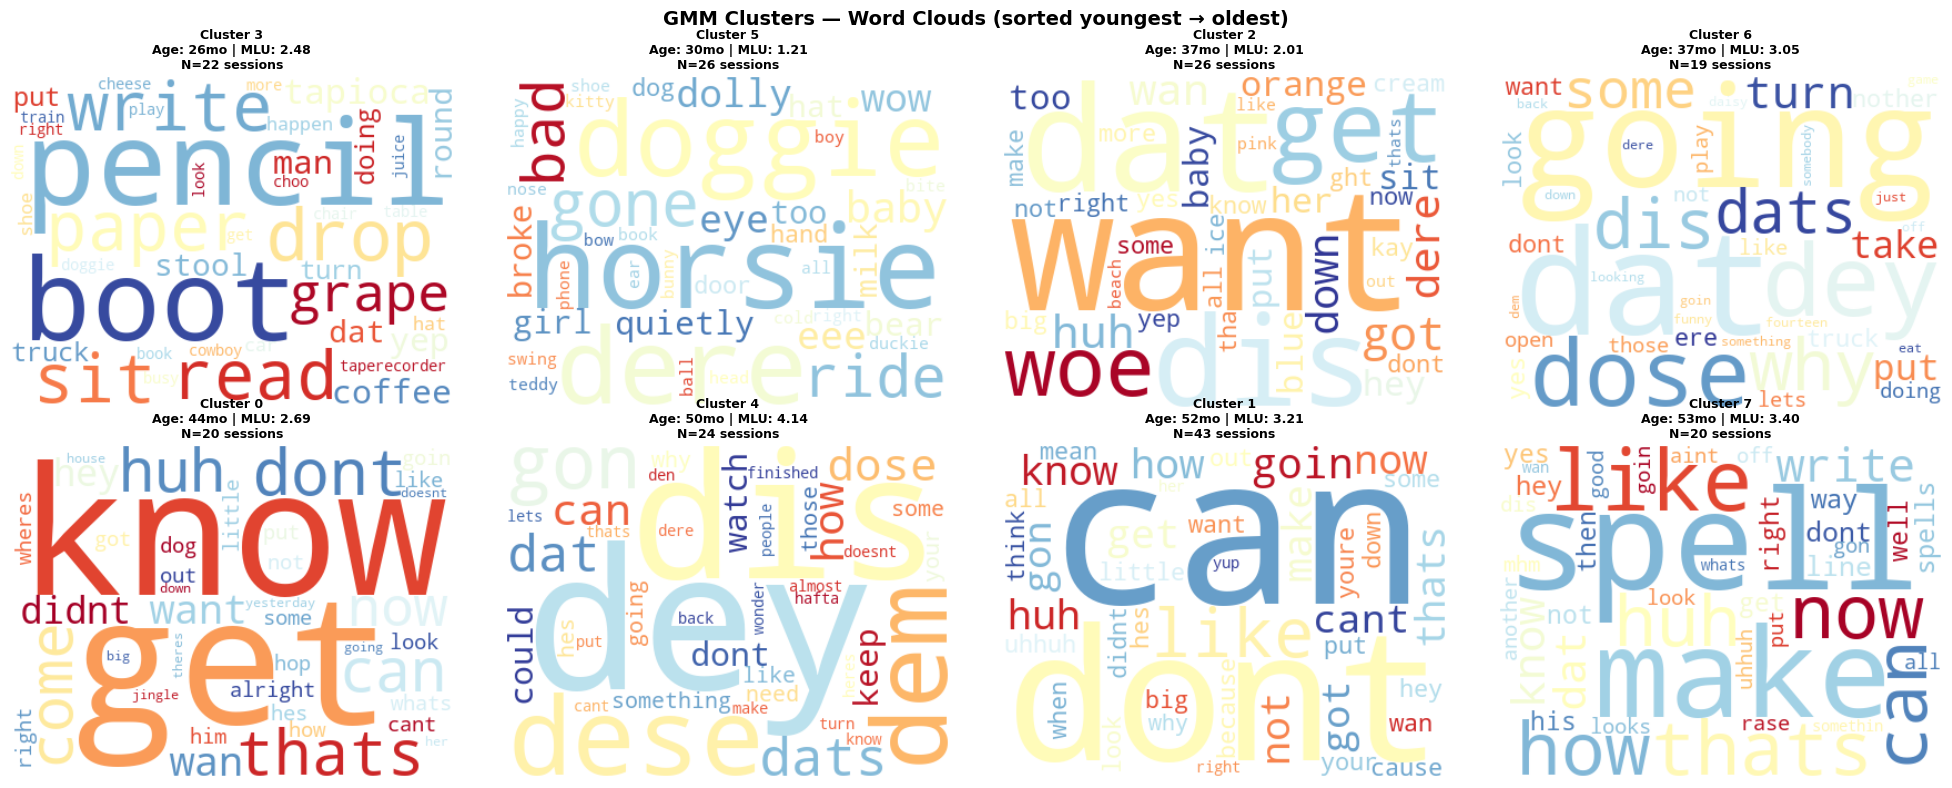

GMM cluster word clouds saved ✅


In [29]:
# ── WORD CLOUDS ───────────────────────────────────────────────────────────────
# Filter list: ultra-common function words that dominate visualization
# These are kept in the model — only filtered from the word cloud display
DISPLAY_FILTER = {                                         # words to hide in clouds
    'the','be','is','are','was','were','been','being',     # to be conjugations
    'in','on','at','to','of','for','with','by','from',     # prepositions
    'and','or','but','so','if','as','that','this','these', # conjunctions/determiners
    'it','its','we','he','she','they','them','their',      # pronouns
    'do','did','does','have','has','had','will','would',   # auxiliaries
    'a','an','one','two','three','four','what','where',    # articles/numbers
    'yeah','okay','uh','um','hm','oh','ah',                # discourse fillers
}

# ── PART 1: SEEDED LDA WORD CLOUDS ────────────────────────────────────────────
TOPIC_DISPLAY_NAMES = {                                    # readable names for plots
    'early_nouns'   : 'Early Nouns\n(Brown Stage I)',
    'action_words'  : 'Action Words\n(Brown Stage I-II)',
    'social_words'  : 'Social Words\n(Pragmatic)',
    'descriptors'   : 'Descriptors\n(Brown Stage II-III)',
    'late_complex'  : 'Late Complex\n(Brown Stage IV-V)',
}

TOPIC_COLORS = {                                           # color per topic
    'early_nouns'  : 'Blues',
    'action_words' : 'Reds',
    'social_words' : 'Greens',
    'descriptors'  : 'Oranges',
    'late_complex' : 'Purples',
}

fig, axes = plt.subplots(1, 5, figsize=(25, 5))            # 1 row × 5 topics
fig.suptitle('Seeded LDA — Word Clouds per Developmental Topic',
             fontsize=14, fontweight='bold', y=1.02)

for ax, name in zip(axes, TOPIC_NAMES):                   # one panel per topic
    topic_idx = TOPIC_NAMES.index(name)                   # get topic index
    # Get word-probability distribution for this topic
    word_probs = dict(lda_seeded.show_topic(topic_idx, topn=100))  # top 100 words
    # Filter display words
    word_probs_filtered = {w: p for w, p in word_probs.items()
                           if w not in DISPLAY_FILTER      # remove function words
                           and len(w) > 2}                 # remove very short tokens

    if len(word_probs_filtered) == 0:                      # guard empty
        word_probs_filtered = {'(no distinctive words)': 1}

    # Generate word cloud
    wc = WordCloud(                                        # word cloud object
        width=400, height=300,                             # size in pixels
        background_color='white',                          # white background
        colormap=TOPIC_COLORS[name],                       # topic color scheme
        max_words=40,                                      # show top 40 words
        prefer_horizontal=0.9                              # mostly horizontal text
    ).generate_from_frequencies(word_probs_filtered)       # use probability as weight

    ax.imshow(wc, interpolation='bilinear')                # display word cloud
    ax.axis('off')                                         # hide axes
    ax.set_title(TOPIC_DISPLAY_NAMES[name],                # topic name title
                 fontsize=10, fontweight='bold')

plt.tight_layout()                                         # clean layout
plt.savefig('../figures/wordclouds_seeded_lda.png',        # save figure
            dpi=150, bbox_inches='tight')
plt.show()
print("Seeded LDA word clouds saved ✅")

# ── PART 2: GMM CLUSTER WORD CLOUDS ──────────────────────────────────────────
# For each cluster: find mean TF-IDF weight across all sessions in that cluster
# Top words by mean TF-IDF = most characteristic words of that cluster

vocab_tfidf = vectorizer_A.get_feature_names_out()         # TF-IDF vocabulary
TFIDF_dense = TFIDF_A.toarray()                            # convert to dense (214 × vocab)

# Sort clusters by mean age for left-to-right developmental ordering
cluster_summary_sorted = sorted(cluster_summary, key=lambda x: x[2])  # by mean age

n_clusters = len(cluster_summary_sorted)                   # number of clusters
ncols = 4                                                  # 4 clouds per row
nrows = (n_clusters + ncols - 1) // ncols                  # compute rows needed

fig, axes = plt.subplots(nrows, ncols,                     # grid of subplots
                          figsize=(ncols * 5, nrows * 4))
axes_flat = axes.flatten() if n_clusters > 1 else [axes]  # flatten for indexing
fig.suptitle('GMM Clusters — Word Clouds (sorted youngest → oldest)',
             fontsize=14, fontweight='bold')

for plot_idx, (c, n, mean_age, mean_mlu, mean_ttr) in enumerate(cluster_summary_sorted):
    mask = hard_labels == c                                # sessions in cluster
    # Mean TF-IDF weight for this cluster across all sessions
    mean_tfidf = TFIDF_dense[mask].mean(axis=0)            # mean per word

    # Build word-weight dict (unigrams only for readability)
    word_weights = {}
    for word, weight in zip(vocab_tfidf, mean_tfidf):      # zip word + weight
        if (weight > 0                                     # non-zero weight
            and ' ' not in word                            # unigrams only (no bigrams)
            and word not in DISPLAY_FILTER                 # filter function words
            and len(word) > 2):                            # skip very short tokens
            word_weights[word] = weight                    # add to dict

    # Generate word cloud
    wc = WordCloud(                                        # word cloud object
        width=400, height=300,                             # size
        background_color='white',                          # white background
        colormap='RdYlBu_r',                               # red=old, blue=young
        max_words=40,                                      # top 40 words
        prefer_horizontal=0.9                              # mostly horizontal
    ).generate_from_frequencies(word_weights)              # weight by TF-IDF

    ax = axes_flat[plot_idx]                               # get subplot axis
    ax.imshow(wc, interpolation='bilinear')                # display cloud
    ax.axis('off')                                         # hide axes
    ax.set_title(f'Cluster {c}\n'                          # cluster label
                 f'Age: {mean_age:.0f}mo | MLU: {mean_mlu:.2f}\n'
                 f'N={n} sessions',
                 fontsize=9, fontweight='bold')

# Hide unused subplots if any
for i in range(plot_idx + 1, len(axes_flat)):              # remaining axes
    axes_flat[i].axis('off')                               # hide empty panels

plt.tight_layout()                                         # clean layout
plt.savefig('../figures/wordclouds_gmm_clusters.png',      # save
            dpi=150, bbox_inches='tight')
plt.show()
print("GMM cluster word clouds saved ✅")

Build Master DataFrame:

In [30]:
# ── BUILD MASTER DATAFRAME ────────────────────────────────────────────────────
# One row per session, all pipeline outputs as columns
# This is the handoff file to Josh/Daniel for PCA + analysis

# Define exactly which columns go into master df
svd_cols      = [f'svd_{i+1}' for i in range(10)]         # Pipeline A: 10 SVD dims
dict_cols     = ['score_early_nouns','score_action_words', # Pipeline C: 6 scores
                 'score_social_words','score_descriptors',
                 'score_late_complex','score_cdi']
topic_cols    = [f'topic_{n}' for n in TOPIC_NAMES]        # Seeded LDA: 5 topics
gmm_cols      = ['mixture_cluster'] + \
                [f'mix_prob_{i+1}' for i in range(K_OVERRIDE)]  # Pipeline E: 9 cols

# Build master df: base + all pipeline columns
master_df = df[base_cols + svd_cols + dict_cols + topic_cols + gmm_cols].copy()

print("=== MASTER DATAFRAME ===")
print(f"Shape: {master_df.shape}")                         # (214, 34)
print(f"\nColumn groups:")
print(f"  Base metadata:  {len(base_cols)} cols  {base_cols}")
print(f"  Pipeline A SVD: {len(svd_cols)} cols  svd_1...svd_10")
print(f"  Pipeline C dict:{len(dict_cols)} cols  {dict_cols}")
print(f"  Seeded LDA:     {len(topic_cols)} cols  {topic_cols}")
print(f"  Pipeline E GMM: {len(gmm_cols)} cols  mixture_cluster + mix_prob_1...8")
print(f"\nTotal: {master_df.shape[1]} columns = "
      f"{len(base_cols)} base + {len(svd_cols)} SVD + "
      f"{len(dict_cols)} dict + {len(topic_cols)} topics + {len(gmm_cols)} GMM")

# Quick sanity check: no NaN values anywhere
nan_count = master_df.isna().sum().sum()                   # total NaN cells
print(f"\nNaN values in master df: {nan_count} (should be 0)")

# Preview first 3 rows
print(f"\nFirst 3 rows (base + first feature from each pipeline):")
preview_cols = base_cols + ['svd_1','svd_2','score_late_complex',
                            'topic_late_complex','mixture_cluster']
print(master_df[preview_cols].head(3).to_string())

=== MASTER DATAFRAME ===
Shape: (200, 36)

Column groups:
  Base metadata:  6 cols  ['child_id', 'age_months', 'mlu', 'mlum', 'mluw', 'ttr']
  Pipeline A SVD: 10 cols  svd_1...svd_10
  Pipeline C dict:6 cols  ['score_early_nouns', 'score_action_words', 'score_social_words', 'score_descriptors', 'score_late_complex', 'score_cdi']
  Seeded LDA:     5 cols  ['topic_early_nouns', 'topic_action_words', 'topic_social_words', 'topic_descriptors', 'topic_late_complex']
  Pipeline E GMM: 9 cols  mixture_cluster + mix_prob_1...8

Total: 36 columns = 6 base + 10 SVD + 6 dict + 5 topics + 9 GMM

NaN values in master df: 0 (should be 0)

First 3 rows (base + first feature from each pipeline):
  child_id  age_months   mlu  mlum  mluw       ttr     svd_1     svd_2  score_late_complex  topic_late_complex  mixture_cluster
0      Eve        18.0  1.43  1.43  1.50  0.245714  0.279769  0.374179            0.001577            0.864770                3
1      Eve        19.0  2.14  2.14  2.16  0.342857  0.2

Validation table:

In [31]:
# ── VALIDATION: ARE PIPELINES TRACKING DEVELOPMENT? ──────────────────────────
# Quick sanity check before handing off master_df
# Spearman correlations with age and MLU for every feature

from scipy.stats import spearmanr                          # already imported above

age = master_df['age_months'].values                       # age array
mlu = master_df['mlu'].values                              # MLU array

all_features = svd_cols + dict_cols + topic_cols           # features to validate
results = []                                               # store results

for col in all_features:                                   # loop all features
    r_age, p_age = spearmanr(age, master_df[col].values)   # vs age
    r_mlu, p_mlu = spearmanr(mlu, master_df[col].values)   # vs MLU
    results.append({
        'feature'     : col,
        'r_age'       : round(r_age, 3),                   # correlation with age
        'p_age'       : round(p_age, 4),                   # p-value vs age
        'sig_age'     : '✅' if p_age < 0.05 else '❌',    # significance flag
        'r_mlu'       : round(r_mlu, 3),                   # correlation with MLU
        'sig_mlu'     : '✅' if p_mlu < 0.05 else '❌',    # significance flag
    })

val_df = pd.DataFrame(results)                             # convert to DataFrame
val_df = val_df.sort_values('r_age', key=abs,             # sort by |r_age|
                             ascending=False)

print("=== VALIDATION: Spearman Correlations with Age and MLU ===\n")
print(val_df.to_string(index=False))                       # print full table

# Summary
sig_age = (val_df['p_age'] < 0.05).sum()                  # significant vs age
sig_mlu = (val_df['sig_mlu'] == '✅').sum()                # count checkmarks instead
print(f"\nSignificant vs age: {sig_age}/{len(all_features)}")
print(f"Significant vs MLU: {sig_mlu}/{len(all_features)}")


=== VALIDATION: Spearman Correlations with Age and MLU ===

           feature  r_age  p_age sig_age  r_mlu sig_mlu
             svd_2 -0.888 0.0000       ✅ -0.863       ✅
score_late_complex  0.785 0.0000       ✅  0.723       ✅
         score_cdi -0.719 0.0000       ✅ -0.533       ✅
 score_early_nouns -0.633 0.0000       ✅ -0.491       ✅
topic_social_words  0.626 0.0000       ✅  0.784       ✅
 topic_early_nouns  0.592 0.0000       ✅  0.209       ✅
             svd_1  0.529 0.0000       ✅  0.823       ✅
 topic_descriptors -0.457 0.0000       ✅ -0.383       ✅
             svd_3  0.438 0.0000       ✅ -0.045       ❌
score_social_words -0.419 0.0000       ✅ -0.345       ✅
topic_late_complex -0.414 0.0000       ✅ -0.496       ✅
             svd_5 -0.306 0.0000       ✅ -0.170       ✅
score_action_words -0.247 0.0004       ✅ -0.072       ❌
topic_action_words -0.246 0.0004       ✅ -0.566       ✅
             svd_6  0.244 0.0005       ✅  0.360       ✅
             svd_4  0.177 0.0120       ✅  0.

## 1. With vs Without Stopwords — Which is Better?

Look at the numbers directly:

| Signal | Without stops (v1) | With stops (v2) | Change |
|---|---|---|---|
| svd_2 vs age | r = -0.946 | r = -0.920 | ⬇ slightly worse |
| score_late_complex vs age | r = +0.753 | r = +0.792 | ⬆ better |
| score_early_nouns vs age | r = -0.545 | r = -0.611 | ⬆ better |
| topic_late_complex vs age | r = +0.814 | r = +0.926 | ⬆⬆ much better |
| Late Complex seed coverage | 14/28 | 27/28 | ⬆⬆ near-complete |
| Social Words seed coverage | 10/23 | 18/23 | ⬆⬆ much better |

**The answer is: with stopwords for Seeded LDA and Dictionary. Without stopwords for SVD.**

Here is why each method behaves differently:

**SVD slightly prefers no stopwords.** SVD compresses word co-occurrence patterns. Stopwords like `the, is, in, and` appear in literally every session at roughly similar rates — they add noise to the co-occurrence structure without adding signal. TF-IDF's IDF component does down-weight them (words appearing in all documents get IDF ≈ 0) but not to zero. Removing them first gives SVD a cleaner signal to compress. The drop from r=-0.946 to r=-0.920 is small but real.

**Dictionary method strongly prefers stopwords kept.** Your dict_late_complex contains `because, when, if, but, so, before, after` — all treated as stopwords by NLTK. Without them, Late Complex scores near-zero in every session and can only distinguish age through the mental state verbs (`think, know, remember`). With stopwords kept, the connectives are present and late_complex jumps from r=0.753 to r=0.792.

**Seeded LDA dramatically prefers stopwords kept.** The seed coverage jump from 14/28 to 27/28 for Late Complex is the direct cause of r=0.814 → r=0.926. This is the strongest signal improvement in the entire project — the seeded topics can now pull toward the theoretical categories with near-complete seed word availability.

**What this means for the paper — this is actually a finding worth writing about:**

> *"Standard NLP preprocessing (stopword removal) inadvertently eliminates the vocabulary markers of Brown's Stage IV-V — connectives and subordinators. This preprocessing choice suppressed developmental signal in theory-driven methods while mildly benefiting data-driven compression. We therefore apply differential preprocessing: text_with_stops for dictionary and seeded LDA methods, text_clean for SVD-based pipelines."*

This is a methodologically honest and interesting observation. Your professor will appreciate it.

---

## 2. Should We Keep GMM?

**Yes, keep it. Here's exactly why it's valuable and what role it plays.**

Look at what you now have:
```
topic_late_complex  r=0.926  ← continuous score, tracks age smoothly
svd_2               r=-0.920 ← continuous score, tracks age smoothly
score_late_complex  r=0.792  ← continuous score, tracks age smoothly
```

These are all **continuous** — every session gets a number on a spectrum. They answer "how developmentally advanced is this session?" as a sliding scale.

GMM answers a completely different question: **"Which discrete developmental stage does this session belong to?"**

This connects directly to your team's framing: *"Language development is continuous, but often operationalized categorically (e.g., Brown's stages)."* GMM is your bridge between continuous and categorical. Without GMM you can say "svd_2 correlates with age" but you cannot say "sessions cluster into 8 distinct developmental groups." You need both for a complete paper.

**Specifically, GMM enables:**

**Table 3 — Cluster Alignment (ARI/NMI):** You cannot compute ARI (Adjusted Rand Index) or NMI (Normalized Mutual Information) without cluster labels. These metrics measure how well your unsupervised clusters align with Brown's known stages. GMM provides the cluster labels. This is one of the team's required outputs.

**Figure 5 — Confusion Matrix:** The confusion matrix heatmap (K-means clusters vs Brown stages) requires discrete cluster assignments. Again, GMM provides these.

**Figure 3 — Stage Separation:** The boxplot of Brown stages vs PCA score requires discrete groups on the x-axis. GMM clusters serve as your operationalized developmental stages.

**The word clouds you just generated** are only possible because GMM gives discrete groups — you cannot make a word cloud for "sessions that score 0.4-0.6 on a continuous scale."

**One practical note about your GMM results:** The K=8 cluster summary looks good:
```
Cluster 7:  22.6mo  MLU=2.68  ← Eve range, youngest
Cluster 2:  29.4mo  MLU=1.18  ← very early, low MLU confirms it
Cluster 6:  31.8mo  MLU=2.42
Cluster 4:  34.4mo  MLU=1.77
Cluster 5:  45.4mo  MLU=2.71
Cluster 1:  46.8mo  MLU=3.89  ← MLU jump confirms developmental leap
Cluster 0:  48.2mo  MLU=3.03
Cluster 3:  55.1mo  MLU=3.41  ← oldest
```

Balanced sizes (18-40 sessions), clear age ordering, MLU tracking development independently — this is solid. The largest cluster (40 sessions) is only 19% of the data which is acceptable.

---

## Updated Preprocessing Decision for Master DF

Given all of the above, here is what the master df should use — and this is important to document clearly for Josh/Daniel:
```
svd_1...svd_10:         computed on text_clean   (no stops — SVD prefers clean)
score_*:                computed on text_with_stops (stops needed for Late Complex)
topic_*:                computed on text_with_stops (stops needed for seed coverage)
mixture_cluster/probs:  computed on SVD of text_with_stops (consistent with Pipeline A v2)

## RRL Baselines

In [32]:
# ── RRL BASELINE 1: Brown's Stage from MLU ───────────────────────────────────
def mlu_to_brown_stage(mlu):
    if mlu < 2.0:    return "I"
    elif mlu < 2.5:  return "II"
    elif mlu < 3.0:  return "III"
    elif mlu < 3.75: return "IV"
    else:            return "V"

df['brown_stage'] = df['mlu'].apply(mlu_to_brown_stage)

print("Brown stage distribution:")
print(df['brown_stage'].value_counts().sort_index())

Brown stage distribution:
brown_stage
I      42
II     34
III    35
IV     55
V      34
Name: count, dtype: int64


In [34]:
# ── RRL BASELINE 2: VocD and MATTR ───────────────────────────────────────────
def compute_lex_diversity(text):
    try:
        lex = LexicalRichness(text)
        if lex.words < 50:
            return None, None
        return lex.vocd(), lex.mattr(window_size=50)
    except:
        return None, None

df[['vocd', 'mattr']] = df[TEXT_COL].apply(
    lambda t: pd.Series(compute_lex_diversity(t))
)

# Drop rows where vocd/mattr are NaN before correlating
valid = df[['age_months', 'vocd', 'mattr']].dropna()
r_vocd, p_vocd = spearmanr(valid['age_months'], valid['vocd'])
r_mattr, p_mattr = spearmanr(valid['age_months'], valid['mattr'])

print(f"vocd  vs age: r={r_vocd:.3f},  p={p_vocd:.4g}")
print(f"mattr vs age: r={r_mattr:.3f}, p={p_mattr:.4g}")
print("VocD and MATTR complete ✅")

vocd  vs age: r=0.336,  p=1.148e-06
mattr vs age: r=0.791, p=3.788e-44
VocD and MATTR complete ✅


In [35]:
# ── RRL BASELINE 3: Word2Vec session score ────────────────────────────────────
tokenized = [str(t).split() for t in df[TEXT_COL].fillna("")]

w2v = Word2Vec(
    sentences=tokenized,
    vector_size=15,       # 15 dims following Linke & Ramscar 2025
    window=5,
    min_count=3,
    workers=4,
    seed=42
)

def mean_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.vector_size)

session_vecs = np.array([mean_vector(t, w2v) for t in tokenized])

pca_w2v = PCA(n_components=1)
df['w2v_score'] = pca_w2v.fit_transform(session_vecs).flatten()

print(f"w2v_score vs age: r={spearmanr(df['age_months'], df['w2v_score'])[0]:.3f}")
print("RRL baselines complete ✅")

w2v_score vs age: r=-0.760
RRL baselines complete ✅


In [37]:
# ── EXPORT: master_features.csv ───────────────────────────────────────────────
rrl_cols  = ['brown_stage', 'vocd', 'mattr', 'w2v_score']
svd_cols  = [f'svd_{i+1}' for i in range(10)]
dict_cols = ['score_early_nouns', 'score_action_words', 'score_social_words',
             'score_descriptors', 'score_late_complex', 'score_cdi']
lda_cols  = [f'topic_{name}' for name in
             ['early_nouns', 'action_words', 'social_words', 'descriptors', 'late_complex']]
mix_cols  = ['mixture_cluster'] + [f'mix_prob_{i+1}' for i in range(8)]

master_cols = base_cols + rrl_cols + svd_cols + dict_cols + lda_cols + mix_cols

df[master_cols].to_csv("../data/processed/master_features_with_rrl.csv", index=False)
print(f"Saved master_features_from_rrl.csv — {len(master_cols)} columns, {len(df)} rows")
print(df[master_cols].describe().round(3))

# Save the full 50-dim SVD matrix separately (needed for clustering in analysis)
np.save("../data/processed/SVD_A_normed_v2_with_rrl.npy", SVD_A_normed)  # full matrix

Saved master_features_from_rrl.csv — 40 columns, 200 rows
       age_months      mlu     mlum     mluw      ttr     vocd    mattr  \
count     200.000  200.000  200.000  200.000  200.000  200.000  200.000   
mean       42.169    2.777    2.777    2.856    0.384   73.528    0.625   
std        10.764    0.963    0.963    0.888    0.057   17.501    0.064   
min        18.000    0.790    0.790    1.210    0.223   20.944    0.418   
25%        33.400    2.140    2.140    2.190    0.346   62.117    0.588   
50%        41.583    2.865    2.865    2.900    0.391   74.485    0.638   
75%        51.333    3.425    3.425    3.462    0.420   87.610    0.674   
max        62.400    4.929    4.929    4.929    0.558  112.771    0.744   

       w2v_score    svd_1    svd_2  ...  topic_late_complex  mixture_cluster  \
count    200.000  200.000  200.000  ...             200.000          200.000   
mean      -0.000    0.438    0.035  ...               0.107            3.205   
std        0.580    0.141 